# humano LLC — Workforce Intelligence Demo
### Built by Anika | Data Science & Business Administration

> **What this notebook shows:**  
> A data intelligence layer built on top of humano's Cost-Per-Unit (CPU) staffing model.  
> This prototype demonstrates how humano can use data to reduce costs, predict worker turnover, and outcompete Capstone Logistics.



> **⚠️ Data Disclaimer**
> All data used in this notebook is completely simulated and does not represent 
> real humano LLC operational data, employees, clients, or financial figures. 
> Site names, worker records, fill rates, costs, and performance metrics are 
> fictional and were created solely for demonstration purposes.
>
> The purpose of this prototype is to show what a data intelligence layer 
> could look like if connected to humano's real operational data. 
> All charts, predictions, and insights would reflect actual performance 
> once integrated with humano's existing systems.


In [19]:
# Install required libraries 
import subprocess
import sys

subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'plotly', 'ipywidgets', 'pandas', 'numpy', 'matplotlib', '--quiet'])
print('All libraries installed!')

All libraries installed!


In [20]:
# Import 
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')


## Section 1 — The Business Problem

The first thing I did was make sure I actually understood humano's business before building anything.So I wrote out what I learned, humano is a 255-person company, your biggest advantage is the CPU model where clients pay per unit of work instead of per hour, and the gap I noticed is that your tech stack right now is pretty basic. You have MySQL and some web tools, but no real analytics layer on top of it.Your biggest competitor, Capstone Logistics, has data from over 600 sites that they use to make decisions. I thought, that's the gap.

## Section 2 — CPU Savings Calculator
### For humano's sales team: show clients exactly how much they save

This first tool I built is actually for your sales team, not for operations.
The idea is simple, when one of your sales reps is sitting across from a potential client, the hardest question they get is 'why should I switch from my current staffing company to humano?' Right now they probably answer that in words. This makes it visual.

You just move the sliders to match that client's warehouse, how many workers they have, what they pay per hour, how long their shifts are, and it automatically calculates exactly how much money they would save with humano's CPU model.

The key insight is this idle time slider. With traditional staffing, a client pays workers even when they're standing around doing nothing. With humano's model, you only pay for actual work done. That's where all the savings come from.
So if I'm a client with 80 workers, 5 shifts a week, paying $20 an hour, with about 20% idle time, I can see right here that I'd save over $150,000 a year just by switching to humano. That's a really powerful conversation to have in a sales meeting.

In [21]:
# CPU SAVINGS CALCULATOR

style = {'description_width': '220px'}
layout = widgets.Layout(width='500px')

workers_slider   = widgets.IntSlider(value=50,  min=10,  max=200, step=5,  description='Workers per shift:',   style=style, layout=layout)
shifts_slider    = widgets.IntSlider(value=5,   min=1,   max=21,  step=1,  description='Shifts per week:',     style=style, layout=layout)
wage_slider      = widgets.IntSlider(value=19,  min=16,  max=30,  step=1,  description='Avg hourly wage ($):',  style=style, layout=layout)
idle_slider      = widgets.IntSlider(value=20,  min=5,   max=40,  step=1,  description='Idle time (%):',       style=style, layout=layout)
hours_slider     = widgets.IntSlider(value=8,   min=4,   max=12,  step=1,  description='Shift length (hrs):',  style=style, layout=layout)

output = widgets.Output()

def calculate(change=None):
    workers = workers_slider.value
    shifts  = shifts_slider.value
    wage    = wage_slider.value
    idle    = idle_slider.value / 100
    hours   = hours_slider.value

    weeks_per_year     = 52
    total_hours_year   = workers * shifts * hours * weeks_per_year
    current_cost       = total_hours_year * wage
    idle_cost          = current_cost * idle
    humano_cost        = current_cost - (idle_cost * 0.63)
    annual_savings     = current_cost - humano_cost
    monthly_savings    = annual_savings / 12
    savings_pct        = (annual_savings / current_cost) * 100

    months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
    trad_monthly   = [round(current_cost / 12)] * 12
    humano_monthly = [round(humano_cost / 12)] * 12

    # ✅ FIX: specs tells plotly col 1 is a bar chart (xy) and col 2 is a pie chart (domain)
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=('Monthly cost: traditional vs humano', 'Where the savings come from'),
        column_widths=[0.6, 0.4],
        specs=[[{'type': 'xy'}, {'type': 'domain'}]]
    )

    fig.add_trace(go.Bar(name='Traditional staffing', x=months, y=trad_monthly,
                         marker_color='#E24B4A', opacity=0.85), row=1, col=1)
    fig.add_trace(go.Bar(name='Humano CPU model', x=months, y=humano_monthly,
                         marker_color='#1D9E75', opacity=0.85), row=1, col=1)

    fig.add_trace(go.Pie(
        labels=['Humano cost', 'You save'],
        values=[round(humano_cost), round(annual_savings)],
        marker_colors=['#1D9E75', '#EAF3DE'],
        textinfo='label+percent',
        hole=0.4
    ), row=1, col=2)

    fig.update_layout(
        height=380,
        title=dict(
            text=f'Annual savings with humano: <b>${annual_savings:,.0f}</b>  ({savings_pct:.1f}% reduction)',
            font=dict(size=15, color='#085041')
        ),
        paper_bgcolor='white',
        plot_bgcolor='white',
        showlegend=True,
        legend=dict(orientation='h', y=-0.15),
        yaxis=dict(tickprefix='$', tickformat=',.0f', gridcolor='#f0f0f0'),
        margin=dict(t=80, b=60)
    )

    with output:
        output.clear_output(wait=True)

        display(HTML(f"""
        <div style='display:flex; gap:20px; margin:16px 0;'>
          <div style='background:#E1F5EE; border-radius:10px; padding:16px 24px; text-align:center; flex:1;'>
            <div style='font-size:12px; color:#085041; text-transform:uppercase; letter-spacing:1px;'>Annual savings</div>
            <div style='font-size:28px; font-weight:600; color:#085041;'>${annual_savings:,.0f}</div>
          </div>
          <div style='background:#fff3e0; border-radius:10px; padding:16px 24px; text-align:center; flex:1;'>
            <div style='font-size:12px; color:#633806; text-transform:uppercase; letter-spacing:1px;'>Monthly savings</div>
            <div style='font-size:28px; font-weight:600; color:#633806;'>${monthly_savings:,.0f}</div>
          </div>
          <div style='background:#f3f0ff; border-radius:10px; padding:16px 24px; text-align:center; flex:1;'>
            <div style='font-size:12px; color:#3C3489; text-transform:uppercase; letter-spacing:1px;'>Cost reduction</div>
            <div style='font-size:28px; font-weight:600; color:#3C3489;'>{savings_pct:.1f}%</div>
          </div>
        </div>
        """))

        fig.show()

        display(HTML(f"""
        <div style='background:#f8f8f8; border-radius:8px; padding:14px 20px; margin-top:10px; font-size:13px; color:#444;'>
          <b>Cost breakdown:</b>&nbsp;&nbsp;
          Traditional annual cost: <b>${current_cost:,.0f}</b> &nbsp;|&nbsp;
          Cost of idle time: <b style='color:#A32D2D;'>${idle_cost:,.0f}</b> &nbsp;|&nbsp;
          Humano CPU cost: <b style='color:#3B6D11;'>${humano_cost:,.0f}</b>
        </div>
        """))

for s in [workers_slider, shifts_slider, wage_slider, idle_slider, hours_slider]:
    s.observe(calculate, names='value')

display(HTML("<h3 style='color:#085041; margin-bottom:8px;'>Adjust the sliders to match your warehouse</h3>"))
display(widgets.VBox([workers_slider, shifts_slider, wage_slider, idle_slider, hours_slider]))
display(output)
calculate()

Output()

## Section 3 — Site Performance Dashboard
### Operations view: which sites are winning and which need help

This second tool is for operations team.
Right now, if something is going wrong at one of the sites,like a low fill rate or workers not showing up, how quickly do you find out? Probably when the client calls to complain, right?
What I built here is a dashboard that shows all your sites in one place. You can see fill rate, CPU cost versus your target, how many units each site completed that week, and turnover risk, all at the same time.
I used color coding to make it instant, green means the site is doing great, orange means watch it, red means someone needs to make a call today. So instead of waiting for a client complaint, your operations manager opens this every morning and knows in 10 seconds which site needs attention.
I used five SoCal sites as examples, Inland Empire, Vernon, Ontario, Long Beach, and Compton. You can see Compton is red across the board, which actually leads into the next section.

In [22]:
# SITE PERFORMANCE DATA

np.random.seed(42)

sites = pd.DataFrame({
    'site': ['Inland Empire DC', 'Vernon Distribution', 'Ontario Freight Hub',
             'Long Beach Port DC', 'Compton Warehouse'],
    'fill_rate':    [98.5, 97.1, 95.3, 91.8, 87.2],
    'cpu_cost':     [0.36, 0.38, 0.39, 0.41, 0.45],
    'cpu_target':   [0.42, 0.42, 0.42, 0.42, 0.42],
    'units_weekly': [4200, 3800, 3500, 2900, 2100],
    'turnover_pct': [8, 10, 13, 17, 24],
    'workers':      [65, 58, 52, 44, 38]
})

def site_color(fill):
    if fill >= 96: return '#1D9E75'
    elif fill >= 92: return '#EF9F27'
    else: return '#E24B4A'

sites['color'] = sites['fill_rate'].apply(site_color)

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        'Fill rate by site (%)',
        'CPU cost: actual vs $0.42 target',
        'Weekly units completed',
        'Turnover risk by site (%)'
    ),
    vertical_spacing=0.18,
    horizontal_spacing=0.12
)

short_names = [s.split()[0] + ' ' + s.split()[1] for s in sites['site']]

fig.add_trace(go.Bar(
    x=sites['fill_rate'], y=short_names,
    orientation='h',
    marker_color=sites['color'],
    text=sites['fill_rate'].apply(lambda x: f'{x}%'),
    textposition='outside',
    showlegend=False
), row=1, col=1)

fig.add_trace(go.Bar(
    name='Actual CPU', x=short_names, y=sites['cpu_cost'],
    marker_color='#378ADD', showlegend=True
), row=1, col=2)
fig.add_trace(go.Scatter(
    name='Target ($0.42)', x=short_names, y=sites['cpu_target'],
    mode='lines', line=dict(color='#E24B4A', dash='dash', width=2),
    showlegend=True
), row=1, col=2)

fig.add_trace(go.Bar(
    x=short_names, y=sites['units_weekly'],
    marker_color='#7F77DD',
    text=sites['units_weekly'].apply(lambda x: f'{x:,}'),
    textposition='outside',
    showlegend=False
), row=2, col=1)

fig.add_trace(go.Bar(
    x=short_names, y=sites['turnover_pct'],
    marker_color=sites['turnover_pct'].apply(
        lambda x: '#E24B4A' if x > 18 else ('#EF9F27' if x > 12 else '#1D9E75')
    ),
    text=sites['turnover_pct'].apply(lambda x: f'{x}%'),
    textposition='outside',
    showlegend=False
), row=2, col=2)

fig.update_layout(
    height=600,
    title='humano site performance dashboard — SoCal region',
    paper_bgcolor='white', plot_bgcolor='white',
    font=dict(size=12),
    legend=dict(orientation='h', y=1.05)
)
fig.update_xaxes(gridcolor='#f5f5f5')
fig.update_yaxes(gridcolor='#f5f5f5')

fig.show()

display(HTML("<br><b>Raw data:</b>"))
display(sites[['site','fill_rate','cpu_cost','units_weekly','turnover_pct','workers']]
        .rename(columns={
            'site':'Site', 'fill_rate':'Fill Rate %',
            'cpu_cost':'CPU Cost $', 'units_weekly':'Units/Week',
            'turnover_pct':'Turnover %', 'workers':'Workers'
        }).style
        .background_gradient(subset=['Fill Rate %'], cmap='RdYlGn')
        .background_gradient(subset=['Turnover %'], cmap='RdYlGn_r')
        .format({'CPU Cost $': '${:.2f}', 'Fill Rate %': '{:.1f}%', 'Turnover %': '{:.0f}%'})
       )

,Site,Fill Rate %,CPU Cost $,Units/Week,Turnover %,Workers
0,Inland Empire DC,98.5%,$0.36,4200,8%,65
1,Vernon Distribution,97.1%,$0.38,3800,10%,58
2,Ontario Freight Hub,95.3%,$0.39,3500,13%,52
3,Long Beach Port DC,91.8%,$0.41,2900,17%,44
4,Compton Warehouse,87.2%,$0.45,2100,24%,38


## Section 4 — Turnover Risk Predictor
### Which workers are about to quit — before it's too late

This one is my favorite because it gets at humano's biggest internal cost, losing workers.
Every time a worker quits, you have to recruit, screen, and train someone new. That's expensive and it hurts your fill rate in the meantime. But the problem is most companies only find out a worker is unhappy when they just don't show up one day.
What I built here predicts who is likely to quit before they actually do.
Each dot on this chart is one worker. I looked at four signals, how often they're showing up for shifts, how their work rate compares to the average, how long they've been with the company, and how many times they've been late recently. I combined those into a risk score.
The bigger and redder the dot, the higher the risk. And the table at the bottom shows you exactly which workers to talk to this week, before they're gone.
This is something Capstone does and humano currently has no version of. And honestly, it's not complicated to build, you just need the data connected in the right way.

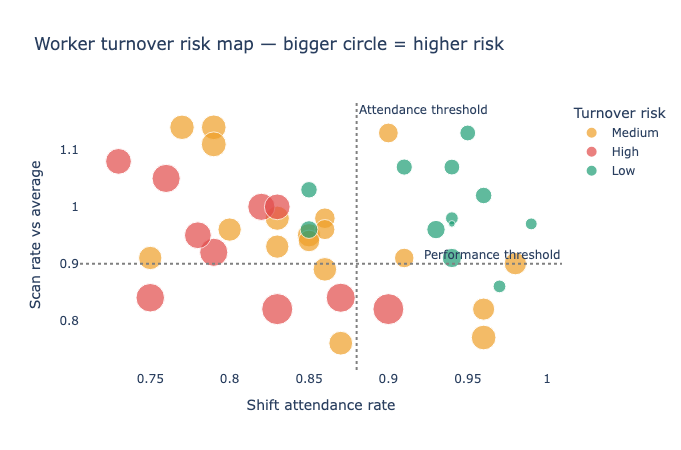

,ID,Site,Risk Score,Attendance,Scan Rate,Tenure (mo)
10,W011,Inland Empire DC,89,83%,0.82,4
3,W004,Long Beach Port DC,88,90%,0.82,1
6,W007,Inland Empire DC,78,87%,0.84,29
20,W021,Inland Empire DC,75,75%,0.84,30
1,W002,Vernon Distribution,73,76%,1.05,24
16,W017,Ontario Freight Hub,73,79%,0.92,20
27,W028,Vernon Distribution,68,82%,1.00,4
23,W024,Long Beach Port DC,66,78%,0.95,3
7,W008,Vernon Distribution,61,73%,1.08,33
28,W029,Compton Warehouse,61,83%,1.00,12


In [23]:
# TURNOVER RISK PREDICTOR

np.random.seed(7)
n = 40

workers_df = pd.DataFrame({
    'worker_id':        [f'W{str(i).zfill(3)}' for i in range(1, n+1)],
    'site':             np.random.choice(['Inland Empire DC','Vernon Distribution',
                                          'Ontario Freight Hub','Long Beach Port DC',
                                          'Compton Warehouse'], n),
    'tenure_months':    np.random.randint(1, 36, n),
    'shift_attendance': np.round(np.random.uniform(0.72, 1.0, n), 2),
    'scan_rate_vs_avg': np.round(np.random.uniform(0.75, 1.15, n), 2),
    'late_arrivals_30d': np.random.randint(0, 8, n),
    'complaints_30d':   np.random.randint(0, 4, n)
})

def turnover_risk(row):
    score = 0
    if row['shift_attendance'] < 0.85:  score += 35
    elif row['shift_attendance'] < 0.92: score += 15
    if row['scan_rate_vs_avg'] < 0.85:  score += 25
    elif row['scan_rate_vs_avg'] < 0.92: score += 10
    if row['tenure_months'] < 3:         score += 20
    elif row['tenure_months'] < 6:       score += 8
    score += row['late_arrivals_30d'] * 4
    score += row['complaints_30d'] * 5
    return min(score, 99)

workers_df['risk_score'] = workers_df.apply(turnover_risk, axis=1)

def risk_label(score):
    if score >= 60: return 'High'
    elif score >= 35: return 'Medium'
    else: return 'Low'

workers_df['risk_level'] = workers_df['risk_score'].apply(risk_label)

color_map = {'High': '#E24B4A', 'Medium': '#EF9F27', 'Low': '#1D9E75'}

fig = px.scatter(
    workers_df,
    x='shift_attendance',
    y='scan_rate_vs_avg',
    color='risk_level',
    color_discrete_map=color_map,
    size='risk_score',
    size_max=22,
    hover_data=['worker_id', 'site', 'tenure_months', 'risk_score'],
    labels={
        'shift_attendance': 'Shift attendance rate',
        'scan_rate_vs_avg': 'Scan rate vs average',
        'risk_level': 'Turnover risk'
    },
    title='Worker turnover risk map — bigger circle = higher risk'
)

fig.add_hline(y=0.90, line_dash='dot', line_color='gray',
              annotation_text='Performance threshold')
fig.add_vline(x=0.88, line_dash='dot', line_color='gray',
              annotation_text='Attendance threshold')

fig.update_layout(
    height=450,
    paper_bgcolor='white',
    plot_bgcolor='white'
)
fig.show()

high_risk = workers_df[workers_df['risk_level'] == 'High'].sort_values('risk_score', ascending=False)

display(HTML(f"<br><h4 style='color:#A32D2D;'>High risk workers — act now ({len(high_risk)} flagged)</h4>"))
display(high_risk[['worker_id','site','risk_score','shift_attendance','scan_rate_vs_avg','tenure_months']]
        .rename(columns={
            'worker_id':'ID', 'site':'Site', 'risk_score':'Risk Score',
            'shift_attendance':'Attendance', 'scan_rate_vs_avg':'Scan Rate',
            'tenure_months':'Tenure (mo)'
        }).style
        .background_gradient(subset=['Risk Score'], cmap='Reds')
        .format({'Attendance': '{:.0%}', 'Scan Rate': '{:.2f}'})
       )

---
## Section 5 — Competitor Analysis
### humano vs Capstone Logistics — where the gap is

I also wanted to be honest about where humano stands versus Capstone right now.
This radar chart scores both companies across six things that matter, data analytics, site coverage, pricing transparency, technology, worker retention, and client reporting.
Humano actually wins on pricing transparency, the CPU model is genuinely better than what Capstone does. But the gaps in data analytics and technology are significant. Capstone scores a 9 in data analytics. Right now humano is at about a 3.
I'm not saying this to be negative, I'm saying it because those gaps are exactly where I think I can add the most value. The good news is humano already has the better business model. It just needs the data infrastructure to match.

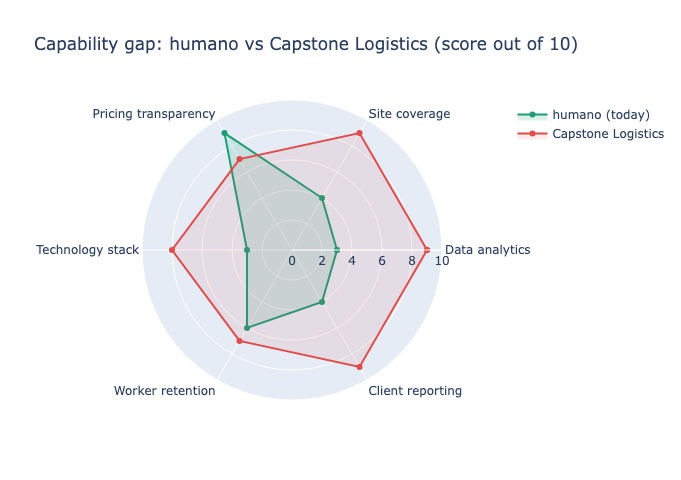

,Capability,Humano,Capstone,Gap
0,Data analytics,3,9,6
1,Site coverage,4,9,5
3,Technology stack,3,8,5
5,Client reporting,4,9,5
4,Worker retention,6,7,1
2,Pricing transparency,9,7,-2


In [18]:
# COMPETITOR GAP ANALYSIS

categories = [
    'Data analytics', 'Site coverage', 'Pricing transparency',
    'Technology stack', 'Worker retention', 'Client reporting'
]

humano_scores   = [3, 4, 9, 3, 6, 4]
capstone_scores = [9, 9, 7, 8, 7, 9]

fig = go.Figure()

fig.add_trace(go.Scatterpolar(
    r=humano_scores + [humano_scores[0]],
    theta=categories + [categories[0]],
    fill='toself',
    name='humano (today)',
    line_color='#1D9E75',
    fillcolor='rgba(29,158,117,0.15)'
))

fig.add_trace(go.Scatterpolar(
    r=capstone_scores + [capstone_scores[0]],
    theta=categories + [categories[0]],
    fill='toself',
    name='Capstone Logistics',
    line_color='#E24B4A',
    fillcolor='rgba(226,75,74,0.1)'
))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 10])),
    showlegend=True,
    title='Capability gap: humano vs Capstone Logistics (score out of 10)',
    height=480,
    paper_bgcolor='white'
)

fig.show()

gap_df = pd.DataFrame({
    'Capability': categories,
    'Humano': humano_scores,
    'Capstone': capstone_scores,
    'Gap': [c - h for h, c in zip(humano_scores, capstone_scores)]
})

display(HTML("<br><b>Where humano needs to close the gap:</b>"))
display(gap_df.sort_values('Gap', ascending=False).style
        .background_gradient(subset=['Gap'], cmap='Reds')
        .bar(subset=['Humano'], color='#1D9E75')
        .bar(subset=['Capstone'], color='#E24B4A')
       )

## Section 6 — My Recommendations for humano

Based on this analysis, here are **3 high-impact things humano should do in 2026:**

### 1. Build a data layer on top of the CPU model
The CPU model is humano's biggest advantage, but right now it generates zero analytical insight. Every CPU transaction should be logged, timestamped, and connected to site, shift, and worker data. This alone would give humano a dataset Capstone took years to build.

### 2. Deploy a turnover early warning system
Worker turnover is humano's biggest internal cost. A simple model using attendance, scan rate, and tenure data (like the one in Section 4 above) could flag at-risk workers 3-4 weeks before they quit,g iving managers time to intervene. Estimated impact: **reduce turnover by 20-30%**, saving hundreds of thousands in re-recruitment costs annually.

### 3. Give clients a live performance portal
Right now humano's clients get reports. Capstone's clients get dashboards. A client-facing portal showing real-time fill rate, CPU cost, and throughput would make humano significantly harder to replace — and justify premium pricing.

---

### What I bring to the table

| Skill | How it applies at humano |
|---|---|
| Python + pandas | Build the data pipeline from MySQL to dashboards |
| Data visualization | Client-facing reporting portals |
| Predictive modeling | Turnover risk, demand forecasting |
| Business strategy | Translate data insights into operational decisions |
| GIS / spatial analysis | Map-based site coverage and labor pool analysis |

---
*Built by Anika | University of Redlands — Data Science & Business Administration, Class of 2026*